In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

#KMNIST Dataset
train_dataset = datasets.KMNIST(root="./data", train=True, transform=transform, download=True)

batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

#Part 1: Exploring Generative Adversarial Networks (GANs) (25%)
#GAN Model Setup

In [ ]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100, img_dim=28*28):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(True),
            nn.Linear(256, 512),
            nn.ReLU(True),
            nn.Linear(512, img_dim),
            nn.Tanh()   # output in [-1, 1]
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, img_dim=28*28):
        super(Discriminator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
gen = Generator().to(device)
disc = Discriminator().to(device)

criterion = nn.BCELoss()
optimizerGen = optim.Adam(gen.parameters(), lr=0.0002)
optimizerDisc = optim.Adam(disc.parameters(), lr=0.0002)

In [ ]:
def saveGeneratorImages(epoch, fixed_noise, folder="outputs"):
    os.makedirs(folder, exist_ok=True)
    gen.eval()
    with torch.no_grad():
        fake = gen(fixed_noise).reshape(-1, 1, 28, 28)
        fake = (fake + 1) / 2.0

    grid = np.transpose(torchvision.utils.make_grid(fake, nrow=8, padding=2, normalize=False).cpu(), (1, 2, 0))
    plt.imshow(grid)
    plt.axis("off")
    plt.savefig(f"{folder}/epoch_{epoch}.png")
    plt.close()
    gen.train()

In [ ]:
import torchvision

epochs = 10
noise_dim = 100
fixed_noise = torch.randn(64, noise_dim).to(device)

for epoch in range(1, epochs+1):
    for batch, _ in train_loader:
        batch = batch.view(-1, 28*28).to(device)
        batch_size = batch.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        outputs = disc(batch)
        loss_real = criterion(outputs, real_labels)

        noise = torch.randn(batch_size, noise_dim).to(device)
        fake = gen(noise)
        outputs = disc(fake.detach())
        loss_fake = criterion(outputs, fake_labels)

        loss_disc = loss_real + loss_fake
        optimizerDisc.zero_grad()
        loss_disc.backward()
        optimizerDisc.step()

        outputs = disc(fake)
        loss_gen = criterion(outputs, real_labels)  # want fake → real
        optimizerGen.zero_grad()
        loss_gen.backward()
        optimizerGen.step()

    print(f"Epoch [{epoch}/{epochs}] Loss D: {loss_disc.item():.4f}, Loss G: {loss_gen.item():.4f}")

    if epoch % 2 == 0:
        saveGeneratorImages(epoch, fixed_noise, folder="Part_1_2_images")

Epoch [1/10] Loss D: 0.3549, Loss G: 3.6684
Epoch [2/10] Loss D: 0.1407, Loss G: 4.8534
Epoch [3/10] Loss D: 0.3913, Loss G: 2.9638
Epoch [4/10] Loss D: 0.0521, Loss G: 4.5567
Epoch [5/10] Loss D: 0.0364, Loss G: 7.5133
Epoch [6/10] Loss D: 0.2759, Loss G: 5.8414
Epoch [7/10] Loss D: 0.3532, Loss G: 7.2613
Epoch [8/10] Loss D: 0.1144, Loss G: 4.0347
Epoch [9/10] Loss D: 0.2072, Loss G: 7.4167
Epoch [10/10] Loss D: 0.1862, Loss G: 4.4576


In [ ]:
#categories
chosen_class = 4
indices = [i for i, (_, label) in enumerate(train_dataset) if label == chosen_class]
subset_dataset = Subset(train_dataset, indices)
subset_loader = DataLoader(subset_dataset, batch_size=batch_size, shuffle=True)

#again training
gen = Generator().to(device)
disc = Discriminator().to(device)
optimizerGen = optim.Adam(gen.parameters(), lr=0.0002)
optimizerDisc = optim.Adam(disc.parameters(), lr=0.0002)

#single class training
epochs = 10
fixed_noise = torch.randn(64, noise_dim).to(device)

for epoch in range(1, epochs+1):
    for batch, _ in subset_loader:
        batch = batch.view(-1, 28*28).to(device)
        batch_size = batch.size(0)

        real_labels = torch.ones(batch_size, 1).to(device)
        fake_labels = torch.zeros(batch_size, 1).to(device)

        # Train Discriminator
        outputs = disc(batch)
        loss_real = criterion(outputs, real_labels)

        noise = torch.randn(batch_size, noise_dim).to(device)
        fake = gen(noise)
        outputs = disc(fake.detach())
        loss_fake = criterion(outputs, fake_labels)

        loss_disc = loss_real + loss_fake
        optimizerDisc.zero_grad()
        loss_disc.backward()
        optimizerDisc.step()

        # Train Generator
        outputs = disc(fake)
        loss_gen = criterion(outputs, real_labels)
        optimizerGen.zero_grad()
        loss_gen.backward()
        optimizerGen.step()

    print(f"[Single Class] Epoch [{epoch}/{epochs}] Loss D: {loss_disc.item():.4f}, Loss G: {loss_gen.item():.4f}")

    if epoch % 2 == 0:
        saveGeneratorImages(epoch, fixed_noise, folder="choosenCategory")

[Single Class] Epoch [1/10] Loss D: 0.2634, Loss G: 2.3666
[Single Class] Epoch [2/10] Loss D: 0.2335, Loss G: 3.0965
[Single Class] Epoch [3/10] Loss D: 0.0676, Loss G: 4.4836
[Single Class] Epoch [4/10] Loss D: 0.2816, Loss G: 3.3473
[Single Class] Epoch [5/10] Loss D: 1.1438, Loss G: 4.8093
[Single Class] Epoch [6/10] Loss D: 0.2013, Loss G: 4.9727
[Single Class] Epoch [7/10] Loss D: 0.0587, Loss G: 4.6261
[Single Class] Epoch [8/10] Loss D: 0.4919, Loss G: 3.4229
[Single Class] Epoch [9/10] Loss D: 3.2046, Loss G: 1.2478
[Single Class] Epoch [10/10] Loss D: 1.7230, Loss G: 1.4709


#Part 1 Tasks

#Task 1

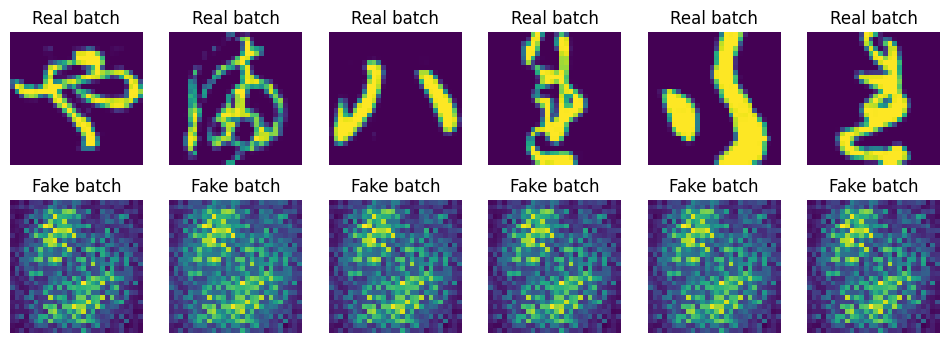

In [ ]:
import matplotlib.pyplot as plt


realBatch, _ = next(iter(train_loader))
realBatch = realBatch[:6]

noise = torch.randn(6, 100).to(device)
fakeBatch = gen(noise).reshape(-1, 1, 28, 28).cpu().detach()

fakeBatch = (fakeBatch + 1) / 2

fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for i in range(6):
    axes[0, i].imshow(realBatch[i][0])
    axes[0, i].set_title("Real batch")
    axes[0, i].axis("off")

    axes[1, i].imshow(fakeBatch[i][0])
    axes[1, i].set_title("Fake batch")
    axes[1, i].axis("off")

plt.show()

#Task 2

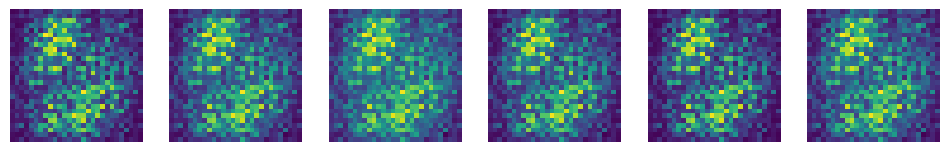

In [ ]:
noise = torch.randn(6, 100).to(device)
samples = gen(noise).reshape(-1, 1, 28, 28).cpu().detach()
samples = (samples + 1) / 2

fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(samples[i][0])
    axes[i].axis("off")
plt.show()

#Part 2: Implementing Variational Autoencoders (VAEs) (25%)
#VAE Model Development

In [ ]:
import torch.nn.functional as F

class VAE(nn.Module):
    def __init__(self, img_dim=28*28, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()
# Encoder
        self.fc1 = nn.Linear(img_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
# Decoder
        self.fc_dec1 = nn.Linear(latent_dim, hidden_dim)
        self.fc_dec2 = nn.Linear(hidden_dim, img_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = F.relu(self.fc_dec1(z))
        recon = torch.sigmoid(self.fc_dec2(h))
        return recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [ ]:
def vaeTraining(model, dataloader, epochs=10, lr=1e-3, device="cpu"):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    recon_losses = []
    kld_losses = []

    for epoch in range(1, epochs+1):
        model.train()
        epoch_recon = 0.0
        epoch_kld = 0.0
        N = 0

        for x, _ in dataloader:
            x = x.view(-1, 28*28).to(device)

            x_in = (x + 1.0) / 2.0

            optimizer.zero_grad()
            recon, mu, logvar = model(x_in)
# reconstruction loss
            recon_loss = F.binary_cross_entropy(recon, x_in, reduction='sum')
# KLD
            kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + kld
            loss.backward()
            optimizer.step()

            epoch_recon += recon_loss.item()
            epoch_kld += kld.item()
            N += x_in.size(0)

        recon_losses.append(epoch_recon / N)
        kld_losses.append(epoch_kld / N)
        print(f"Epoch [{epoch}/{epochs}] Recon: {recon_losses[-1]:.4f}, KLD: {kld_losses[-1]:.4f}")

    return model, recon_losses, kld_losses


Epoch [1/10] Recon: 255.8941, KLD: 17.0234
Epoch [2/10] Recon: 196.6305, KLD: 26.9703
Epoch [3/10] Recon: 187.5457, KLD: 28.2893
Epoch [4/10] Recon: 183.2377, KLD: 28.8720
Epoch [5/10] Recon: 180.5344, KLD: 29.2469
Epoch [6/10] Recon: 178.6227, KLD: 29.4645
Epoch [7/10] Recon: 177.2412, KLD: 29.6285
Epoch [8/10] Recon: 176.0712, KLD: 29.7547
Epoch [9/10] Recon: 175.1682, KLD: 29.8824
Epoch [10/10] Recon: 174.3777, KLD: 29.9614


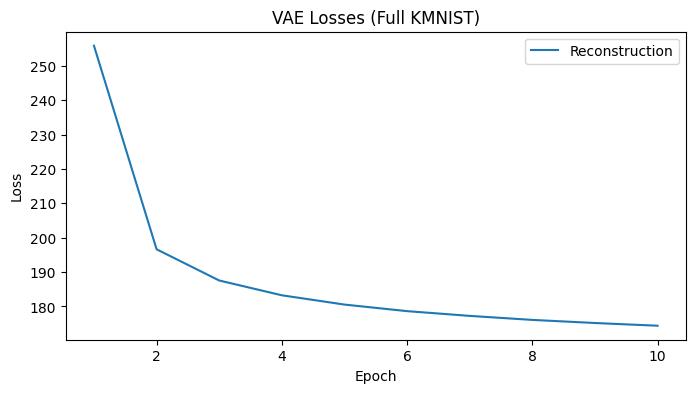

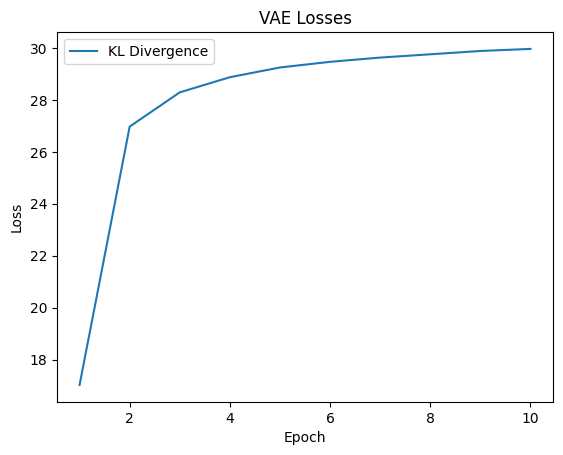

In [ ]:
vae = VAE(latent_dim=20)
device = "cuda" if torch.cuda.is_available() else "cpu"

vae, recon_full, kld_full = vaeTraining(vae, train_loader, epochs=10, lr=1e-3, device=device)

# Plotting kl and reconstrucion losses
plt.figure(figsize=(8,4))
plt.plot(range(1, len(recon_full)+1), recon_full, label="Reconstruction")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Losses (Full KMNIST)")
plt.legend()
plt.show()

plt.plot(range(1, len(kld_full)+1), kld_full, label="KL Divergence")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Losses")
plt.legend()
plt.show()

Epoch [1/10] Recon: 333.1446, KLD: 8.4969
Epoch [2/10] Recon: 263.4210, KLD: 16.9149
Epoch [3/10] Recon: 238.1759, KLD: 21.2583
Epoch [4/10] Recon: 222.0754, KLD: 23.9735
Epoch [5/10] Recon: 211.7793, KLD: 25.7547
Epoch [6/10] Recon: 204.7449, KLD: 26.7538
Epoch [7/10] Recon: 199.4097, KLD: 27.5942
Epoch [8/10] Recon: 195.8088, KLD: 28.2478
Epoch [9/10] Recon: 193.2962, KLD: 28.5837
Epoch [10/10] Recon: 190.8857, KLD: 28.9568


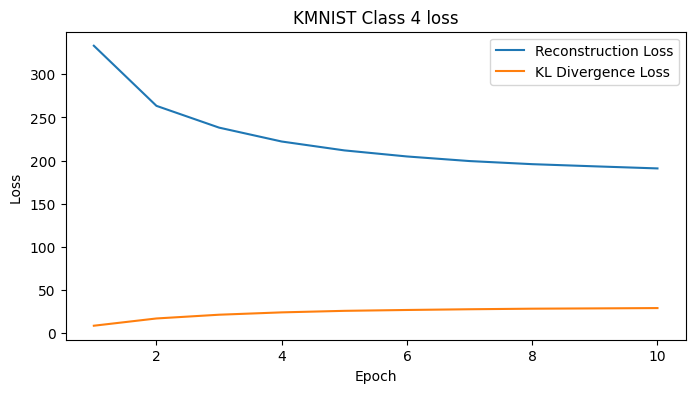

In [ ]:
chosen_class = 4

indices = [i for i, (_, label) in enumerate(train_dataset) if label == chosen_class]
subset_dataset = Subset(train_dataset, indices)
subset_loader = DataLoader(subset_dataset, batch_size=batch_size, shuffle=True)

vae_class = VAE(latent_dim=20).to(device)

vae_class, recon_class, kld_class = vaeTraining(vae_class, subset_loader, epochs=10, lr=1e-3, device=device)

plt.figure(figsize=(8,4))
plt.plot(range(1, len(recon_class)+1), recon_class, label="Reconstruction Loss")
plt.plot(range(1, len(kld_class)+1), kld_class, label="KL Divergence Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss ")
plt.title(f"KMNIST Class {chosen_class} loss")
plt.legend()
plt.show()

#Part 2 Tasks

#Task 1

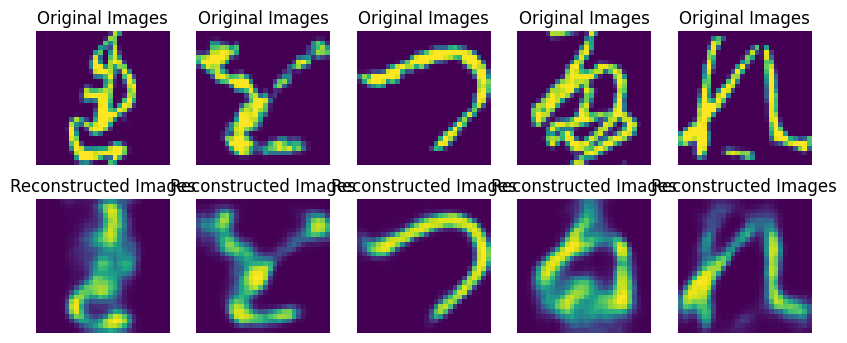

In [ ]:
vae.eval()
with torch.no_grad():

    x, _ = next(iter(train_loader))
    x = x[:5].to(device)

    x_in = (x.view(-1, 28*28) + 1.0) / 2.0
    recon, mu, logvar = vae(x_in)
    recon = recon.view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i in range(5):

    axes[0, i].imshow(((x[i].cpu() + 1) / 2)[0])
    axes[0, i].set_title("Original Images")
    axes[0, i].axis("off")

    axes[1, i].imshow(recon[i][0])
    axes[1, i].set_title("Reconstructed Images")
    axes[1, i].axis("off")

plt.show()

#Task 2

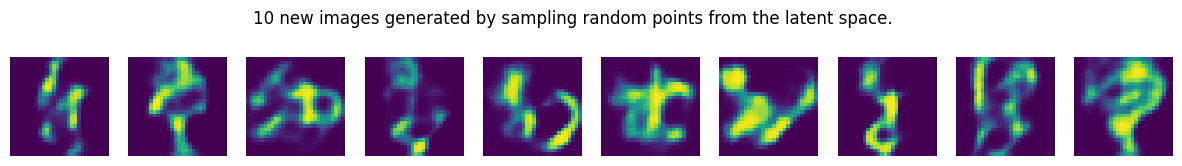

In [ ]:
vae.eval()
with torch.no_grad():
    z = torch.randn(10, 20).to(device)
    existingImages = vae.decode(z).view(-1, 1, 28, 28).cpu()

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(existingImages[i][0])
    axes[i].axis("off")

plt.suptitle("10 new images generated by sampling random points from the latent space.")
plt.show()

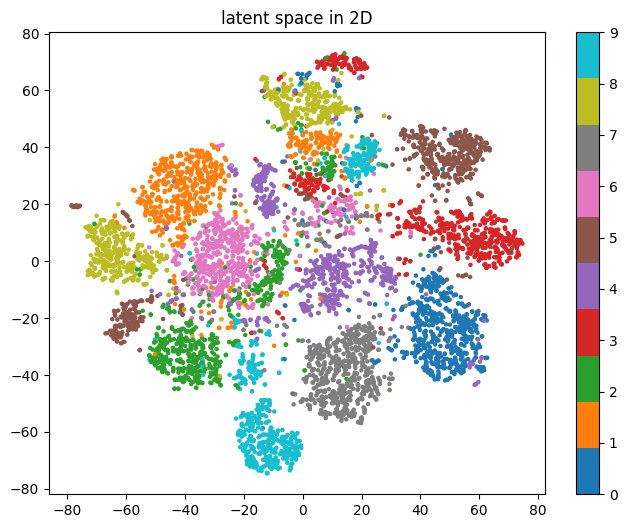

In [ ]:
from sklearn.manifold import TSNE
import numpy as np

vae.eval()
latents = []
labels = []

with torch.no_grad():
    for x, y in train_loader:
        x = x.view(-1, 28*28).to(device)
        x_in = (x + 1.0) / 2.0
        mu, logvar = vae.encode(x_in)
        z = vae.reparameterize(mu, logvar)
        latents.append(z.cpu().numpy())
        labels.append(y.numpy())

        if len(latents) > 50:
            break

latents = np.concatenate(latents, axis=0)
labels = np.concatenate(labels, axis=0)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latents_2d = tsne.fit_transform(latents)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents_2d[:, 0], latents_2d[:, 1], c=labels, cmap="tab10", s=5)
plt.colorbar(scatter, ticks=range(10))
plt.title("latent space in 2D")
plt.show()

#Part 4: VAE for Anomaly Detection (30%)
#Task 4

Epoch [1/5] Recon: 255.9204, KLD: 14.8528
Epoch [2/5] Recon: 234.9973, KLD: 15.7407
Epoch [3/5] Recon: 231.1653, KLD: 15.9106
Epoch [4/5] Recon: 229.2456, KLD: 15.9742
Epoch [5/5] Recon: 228.0345, KLD: 16.0538
Normal Error: 1866.47
Anomalous Error: 3366.58


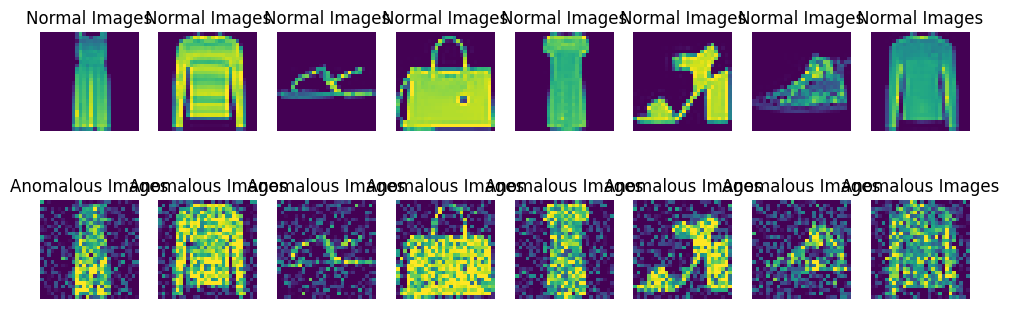

In [ ]:
20#Loading fashion mnist dataset
fashion_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
fashion_loader = DataLoader(fashion_dataset, batch_size=batch_size, shuffle=True)

vae_fashion = VAE(latent_dim=20).to(device)
vae_fashion, recon_losses_fashion, kld_losses_fashion = vaeTraining(
    vae_fashion, fashion_loader, epochs=5, lr=1e-3, device=device
)

data_iter = iter(fashion_loader)
normal_images, _ = next(data_iter)
normal_images = normal_images[:8].to(device)

anomalous_images = normal_images.clone()
anomalous_images = anomalous_images + 0.5 * torch.randn_like(anomalous_images)
anomalous_images = torch.clamp(anomalous_images, -1, 1)

vae_fashion.eval()
with torch.no_grad():

#Normal Data
    x_norm = normal_images.view(-1, 28*28)
    x_norm_in = (x_norm + 1.0) / 2.0
    recon_norm, mu_norm, logvar_norm = vae_fashion(x_norm_in)
    loss_norm = F.binary_cross_entropy(recon_norm, x_norm_in, reduction="sum")
    kld_norm = -0.5 * torch.sum(1 + logvar_norm - mu_norm.pow(2) - logvar_norm.exp())
    total_norm = (loss_norm + kld_norm).item()

#Salted Data
    x_anom = anomalous_images.view(-1, 28*28)
    x_anom_in = (x_anom + 1.0) / 2.0
    recon_anom, mu_anom, logvar_anom = vae_fashion(x_anom_in)
    loss_anom = F.binary_cross_entropy(recon_anom, x_anom_in, reduction="sum")
    kld_anom = -0.5 * torch.sum(1 + logvar_anom - mu_anom.pow(2) - logvar_anom.exp())
    total_anom = (loss_anom + kld_anom).item()

print(f"Normal Error: {total_norm:.2f}")
print(f"Anomalous Error: {total_anom:.2f}")

fig, axes = plt.subplots(2, 8, figsize=(12, 4))
with torch.no_grad():
    recon_norm_imgs = recon_norm.view(-1, 1, 28, 28).cpu()
    recon_anom_imgs = recon_anom.view(-1, 1, 28, 28).cpu()

for i in range(8):
    axes[0, i].imshow(normal_images[i].cpu().squeeze())
    axes[0, i].set_title("Normal Images")
    axes[0, i].axis("off")

    axes[1, i].imshow(anomalous_images[i].cpu().squeeze())
    axes[1, i].set_title("Anomalous Images")
    axes[1, i].axis("off")

plt.show()